# 02 — Inspect Functional Images

**Purpose:** Visually verify that the preprocessed BOLD images and brain masks look correct before fitting any model. Catching a bad image now is much better than discovering it after a long model fit.

This notebook is purely diagnostic — it produces no analysis outputs, only figures. It is nearly identical in spirit to the equivalent notebook from the basic GLM workflow, but is repeated here so the beta-series pipeline is self-contained.

**What you are checking:**
1. That each BOLD image loads and the mean functional image looks like a brain
2. That the brain mask covers the brain correctly with no obvious gaps or over-coverage
3. That the functional image and the T1w anatomical are well-aligned in MNI space

**Output:** Figures saved to `Analysis/outputs/{subject}/beta_series/figures/inspection/`

---
## Section 1 — Configuration and Paths

Here are all the paths you need to define for `sub-097`:

**Preprocessed BOLD images:**
```
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
```

**Brain masks:**
```
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz
```

**T1w anatomical (MNI space):**
```
C:\ManzaRotation\Derivatives\sub-097\anat\sub-097_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz
```

**Inspection figures output:**
```
C:\ManzaRotation\Analysis\outputs\sub-097\beta_series\figures\inspection\
```

Build all of these from `subject` so they stay general:

```python
project_dir    = Path(r"C:\ManzaRotation")
func_deriv_dir = project_dir / "Derivatives" / subject / "func"
anat_deriv_dir = project_dir / "Derivatives" / subject / "anat"
anat_path      = anat_deriv_dir / f"{subject}_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"

inspection_dir = project_dir / "Analysis" / "outputs" / subject / "beta_series" / "figures" / "inspection"
inspection_dir.mkdir(parents=True, exist_ok=True)
```

**TODO:**
- [ ] Set `subject`
- [ ] Define all of the above as `Path` objects using this pattern
- [ ] Call `.mkdir(parents=True, exist_ok=True)` on `inspection_dir`

In [12]:
from pathlib import Path

subject = "sub-097"
tasks = ["modulate1", "modulate2"]

project_dir = Path("C:\\ManzaRotation")
func_deriv_dir = project_dir / "Derivatives" / subject / "func"
anat_deriv_dir = project_dir / "Derivatives" / subject / "anat"
anat_path      = anat_deriv_dir / f"{subject}_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"

inspection_dir = project_dir / "Analysis" / "outputs" / subject / "beta_series" / "figures" / "inspection"
inspection_dir.mkdir(parents=True, exist_ok=True)


---
## Section 2 — Load and Visualize Mean Functional Images

The BOLD image is 4D (x, y, z, time). Computing the mean across time gives you a 3D snapshot that's easy to inspect visually.

The two BOLD files you are loading are:
```
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
```

Computing and plotting the mean looks like this:

```python
bold1_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"

mean_func_1 = mean_img(bold1_path)   # collapses the time dimension
plot_img(mean_func_1, title="Mean functional - modulate1")
show()
```

**TODO:**
- [ ] Build both BOLD paths and compute `mean_func_1` and `mean_func_2`
- [ ] Call `plot_img` and `show()` for each — confirm they look like brains

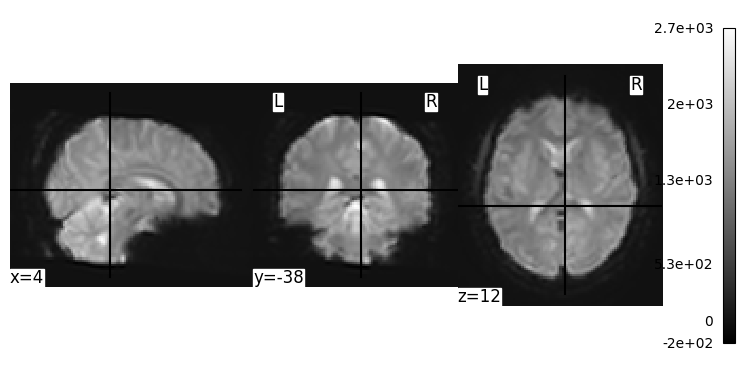

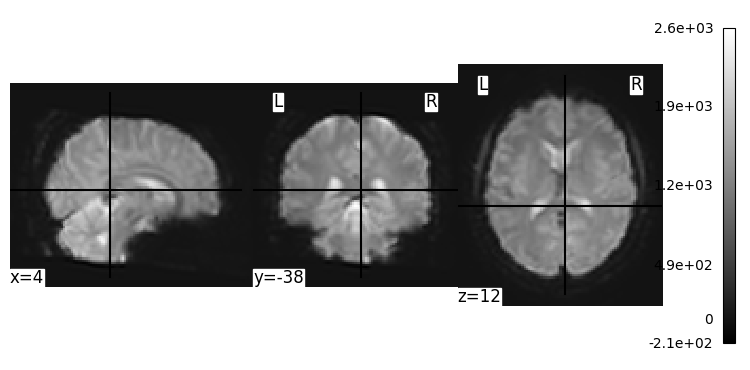

In [13]:
from nilearn.image import mean_img
from nilearn.plotting import plot_img, show


bold1_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"
bold2_path = func_deriv_dir / f"{subject}_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"

mean_func_1 = mean_img(bold1_path)
mean_func_2 = mean_img(bold2_path)

display1 = plot_img(mean_func_1)
display1.savefig(inspection_dir / f"{subject}_modulate1_mean_func.png")
show()
display2 =plot_img(mean_func_2)
display2.savefig(inspection_dir / f"{subject}_modulate2_mean_func.png")
show()

---
## Section 3 — Check Brain Mask Coverage

The brain mask defines which voxels will be included in the GLM. The two mask files are:
```
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz
C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz
```

`plot_roi` overlays a binary mask (in color) on a background image. Pass the mean functional as the background:

```python
mask1_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"

plot_roi(mask1_path, bg_img=mean_func_1, title="Brain mask - modulate1")
show()
```

**What to look for:**
- The colored overlay should cover grey and white matter
- Cerebellum and frontal poles should be included
- Eyes, sinuses, and neck should not be included

**TODO:**
- [ ] Build both mask paths
- [ ] Call `plot_roi` for each and `show()`

In [25]:
from nilearn.plotting import plot_roi

mask1_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"
mask2_path = func_deriv_dir / f"{subject}_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"
print(mask1_path)
plot_roi(mask1_path, bg_img = mean_func_1, title = "Brain Mask Modulate 1", output_file = inspection_dir / f"{subject}_brain_mask_modulate1.png")
show()
plot_roi(mask2_path, bg_img = mean_func_2, title = "Brain Mask Modulate 2", output_file = inspection_dir / f"{subject}_brain_mask_modulate2.png")
show()

C:\ManzaRotation\Derivatives\sub-097\func\sub-097_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz


---
## Section 4 — Check Functional-Anatomical Alignment

Since both the BOLD and T1w images are in MNI space after fMRIPrep preprocessing, they should be well-aligned. The T1w anatomical you are using is:

```
C:\ManzaRotation\Derivatives\sub-097\anat\sub-097_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz
```

Pass the anatomical as `bg_img` to overlay the mean functional on top of it:

```python
plot_img(
    mean_func_1,
    bg_img=anat_path,
    title="Mean functional modulate1 on anatomy",
    cbar_tick_format="%i",
)
show()
```

**What to look for:**
- Sulci and gyri in the functional should line up with the anatomical
- No obvious shift or rotation between the two images

**TODO:**
- [ ] Confirm `anat_path.exists()` before plotting
- [ ] Call `plot_img` with `bg_img=anat_path` for both runs and `show()`

In [26]:
plot_img(
    mean_func_1,
    bg_img = anat_path,
    title = "Mean Functional Image 1",
    cbar_tick_format ="%i",
    output_file = inspection_dir / f"{subject}_mean_func_1.png"
)
plot_img(
    mean_func_2,
    bg_img = anat_path,
    title = "Mean Functional Image 2",
    cbar_tick_format ="%i",
    output_file = inspection_dir / f"{subject}_mean_func_2.png"
)
